In [12]:
import pandas as pd
import numpy as np
import re
import pickle
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, LSTM, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [13]:
df = pd.read_csv('YoutubeCommentsDataSet.csv')

In [14]:
import re

def clean_text(Comment):
    if isinstance(Comment, str):  # Check if Comment is a string
        text = Comment.lower()  # Convert to lowercase
        text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
        return text.strip()
    else:
        return ""  # Return empty string for non-string values

df['Comment'] = df['Comment'].apply(clean_text)


In [15]:
df['Sentiment'] = df['Sentiment'].astype(str)  # Ensure labels are strings
label_encoder = LabelEncoder()
df['Sentiment'] = label_encoder.fit_transform(df['Sentiment'])  # Encode labels
num_classes = len(label_encoder.classes_)

In [16]:
# Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

In [17]:
# ✅ Step 3: Tokenize & Pad Text Data
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['Comment'])

In [18]:
# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

x_data = tokenizer.texts_to_sequences(df['Comment'])
x_data = pad_sequences(x_data, padding='post', maxlen=100)  # Adjust maxlen as needed

In [19]:
x_data = tokenizer.texts_to_sequences(df['Comment'])
x_data = pad_sequences(x_data, padding='post', maxlen=100)  # Adjust maxlen as needed

In [20]:
# Convert labels to categorical
y_data = to_categorical(df['Sentiment'], num_classes=num_classes)

In [21]:
# ✅ Step 4: Split Data
x_train, x_valid, y_train, y_valid = train_test_split(x_data, y_data, test_size=0.2, random_state=42)


In [22]:
# ✅ Step 5: Define CNN Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),  # Embedding Layer
    Conv1D(64, 5, activation='relu'),  # Convolutional Layer
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # Output Layer
])

c:\Users\gr064\OneDrive\Desktop\Sentiment Analysis\tf_env\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,056,139 (7.84 MB)

 Trainable params: 685,379 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,370,760 (5.23 MB)

In [24]:
# ✅ Step 6: Compile Model
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])

In [25]:
# ✅ Step 7: Train Model
history = model.fit(x_train, y_train, batch_size=64, epochs=10, validation_data=(x_valid, y_valid))

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.6172 - loss: 0.8673 - val_accuracy: 0.7295 - val_loss: 0.6296
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7658 - loss: 0.5633 - val_accuracy: 0.7529 - val_loss: 0.5733
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8393 - loss: 0.3989 - val_accuracy: 0.7602 - val_loss: 0.5876
Epoch 4/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9178 - loss: 0.2474 - val_accuracy: 0.7539 - val_loss: 0.6481
Epoch 5/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9603 - loss: 0.1387 - val_accuracy: 0.7512 - val_loss: 0.8429
Epoch 6/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9699 - loss: 0.0909 - val_accuracy: 0.7542 - val_loss: 0.9098
Epoch 7/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9861 - loss: 0.0506 - val_accuracy: 0.7452 - val_loss: 1.0737
Epoch 8/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9888 - loss: 0.0380 - val_accu

In [26]:
# ✅ Step 8: Evaluate Model
score = model.evaluate(x_valid, y_valid, verbose=0)
print('Test Loss:', score[0])
print('Test Accuracy:', score[1])

Test Loss: 1.3219749927520752
Test Accuracy: 0.7428027987480164


In [27]:
# ✅ Step 9: Save Model
model.save('sentiment_model.h5')

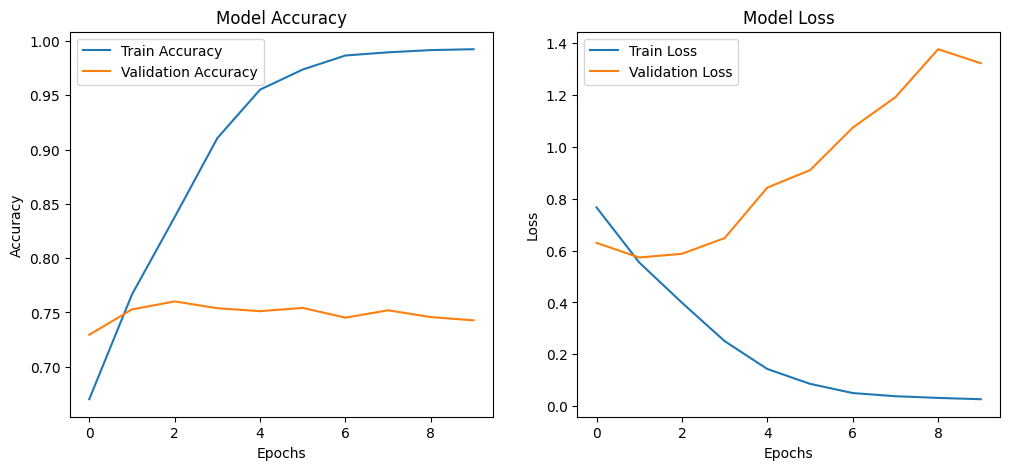

In [28]:
# ✅ Step 10: Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [73]:
y_hat = model.predict(x_valid)
y_hat1 = pd.DataFrame(data=y_hat)
y_hat1[0]=y_hat1[0].apply(lambda a:0 if a<=0.5 else 1)
y_hat2 = y_hat1[0]

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [76]:
print(y_hat2.shape)  # Debugging: Check if it's 1D or 2D


(3682,)


In [77]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# ✅ Convert y_valid from one-hot encoding to categorical labels
y_valid_labels = np.argmax(y_valid, axis=1)

# ✅ Ensure y_hat2 is categorical
if len(y_hat2.shape) > 1:  # Check if it's one-hot encoded
    y_hat2_labels = np.argmax(y_hat2, axis=1)
else:
    y_hat2_labels = y_hat2  # Already categorical, no need to apply argmax

# ✅ Now compute confusion matrix & classification report
print(confusion_matrix(y_valid_labels, y_hat2_labels))
print(classification_report(y_valid_labels, y_hat2_labels))


[[ 307  168    0]
 [ 875   62    0]
 [2230   40    0]]
              precision    recall  f1-score   support

           0       0.09      0.65      0.16       475
           1       0.23      0.07      0.10       937
           2       0.00      0.00      0.00      2270

    accuracy                           0.10      3682
   macro avg       0.11      0.24      0.09      3682
weighted avg       0.07      0.10      0.05      3682



c:\Users\gr064\OneDrive\Desktop\Sentiment Analysis\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gr064\OneDrive\Desktop\Sentiment Analysis\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gr064\OneDrive\Desktop\Sentiment Analysis\tf_env\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av